# Bivariate analyse van Minecraft speedrun-data

In deze notebook voeren we een **bivariate analyse** uit op een dataset met Minecraft speedruns. We onderzoeken relaties tussen:

- Twee numerieke variabelen (scatterplot + regressielijn)
- Een categorische en een numerieke variabele (barplot, boxplot, violinplot)
- Twee categorische variabelen (gestapelde barplot)

We gebruiken hiervoor de dataset `Own_Project/mce.csv` (pas het pad aan als jouw bestand ergens anders staat).

## 1. Data inladen en datacontrole

We lezen eerst de data in met `pandas` en voeren een aantal basale controles uit:

- Overzicht van kolommen en datatypes
- Controle op missende waarden
- Controle of de tijdsvariabele (`speedrun_time`) realistische waarden heeft


In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Zorg dat grafieken in de notebook worden getoond
%matplotlib inline

# Laad de dataset (pas het pad aan indien nodig)
df = pd.read_csv('mce.csv')

print('Vorm van de data:', df.shape)
print('\nKolommen en datatypes:')
print(df.dtypes)

print('\nAantal missende waarden per kolom:')
print(df.isna().sum())

# Basisstatistieken voor de tijdsvariabele
print('\nSamenvatting speedrun_time:')
print(df['speedrun_time'].describe())

Vorm van de data: (3307, 24)

Kolommen en datatypes:
run_id                     object
player_id                  object
place                       int64
speedrun_time             float64
is_verified                  bool
verify_date                object
submitted_date             object
examiner_id                object
timing_type                object
platform_id                object
platform_name              object
platform_released_year      int64
is_level_cat                 bool
level_id                   object
level_name                 object
level_rules               float64
game_id                    object
category_id                object
cat_name                   object
cat_rules                  object
player_name                object
player_country             object
player_pronouns            object
player_signup_date         object
dtype: object

Aantal missende waarden per kolom:
run_id                       0
player_id                 3003
place              

### 1.1 Tijdsvariabele omzetten naar minuten

`speedrun_time` lijkt in **seconden** te staan (waarden rond 80–110 voor veel runs, met een maximum rond 40.000 seconden ≈ 11 uur). We voegen daarom een kolom `time_min` toe door te delen door 60.


In [115]:
# Voeg kolom met tijd in minuten toe
df['time_min'] = df['speedrun_time'] / 60

print(df[['speedrun_time', 'time_min']].head())
print('\nSamenvatting time_min:')
print(df['time_min'].describe())

   speedrun_time  time_min
0           98.0  1.633333
1          100.0  1.666667
2          103.0  1.716667
3          103.0  1.716667
4          106.0  1.766667

Samenvatting time_min:
count    3307.000000
mean        3.874104
std        17.128473
min         0.000017
25%         1.420342
50%         1.674983
75%         1.798717
max       672.000000
Name: time_min, dtype: float64


### 1.2 Selectie top 100 per leaderboard-plaats

Voor veel analyses focussen we op runs met een **plaats ≤ 100** op het leaderboard. We maken hiervoor een subset `df_top100`.


In [116]:
df_top100 = df[df['place'] <= 100].copy()
print('Vorm df_top100:', df_top100.shape)
print('\nCategorieën in cat_name:')
print(df_top100['cat_name'].value_counts())

Vorm df_top100: (607, 25)

Categorieën in cat_name:
cat_name
Time Attack                     301
Kill Bosses                      65
Any% Tutorial World              57
Random Seed Any% Glitchless      54
Set Seed Any%                    50
Random Seed Any%                 30
Set Seed Any% Glitchless         25
Achievements                     14
Glide (Basic)                     8
Glide (100%)                      2
Kill Wither (Horse Tutorial)      1
Name: count, dtype: int64


## 2. Bivariate analyse: twee numerieke variabelen

We onderzoeken de relatie tussen:

- `place` (rang op het leaderboard; 1 = beste)
- `time_min` (looptijd in minuten)

Een logische verwachting is dat **hogere tijden horen bij slechtere plaatsen**. We beperken ons tot de categorie **'Time Attack'** binnen de top 100, omdat dit de grootste categorie is en zo verschillen tussen categorieën geen ruis veroorzaken.


In [117]:
# Filter op Time Attack binnen de top 100
df_ta = df_top100[df_top100['cat_name'] == 'Time Attack'].copy()
print('Aantal Time Attack-runs in top 100:', len(df_ta))

# Correlatie tussen plaats en tijd
corr = df_ta[['place', 'time_min']].corr()
print('\nCorrelatiematrix (Time Attack, top 100):')
print(corr)

Aantal Time Attack-runs in top 100: 301

Correlatiematrix (Time Attack, top 100):
             place  time_min
place     1.000000  0.580989
time_min  0.580989  1.000000


### 2.1 Scatterplot + regressielijn (regplot)

We maken een scatterplot met `place` op de x-as en `time_min` op de y-as. Daarnaast tekenen we een **lineaire regressielijn** door de punten om het patroon duidelijker te zien.


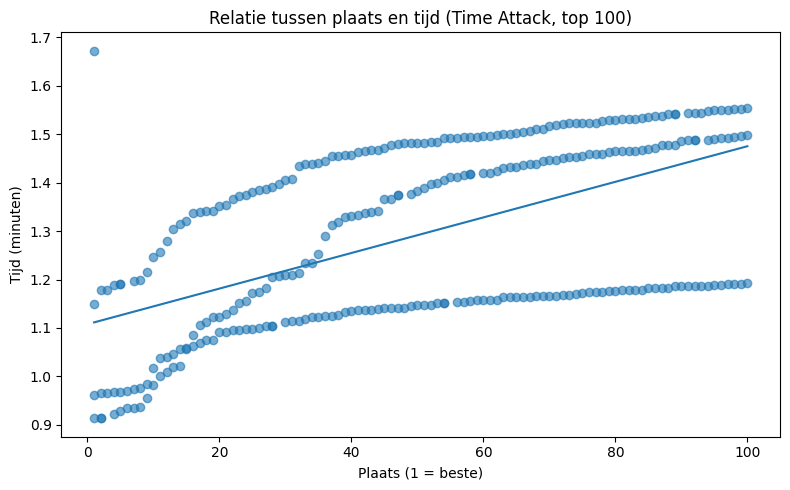

Regressielijn: time_min = 0.0037 * place + 1.1078


In [118]:
# Scatterplot met regressielijn voor Time Attack top 100
x = df_ta['place'].values
y = df_ta['time_min'].values

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, alpha=0.6)

# Lineaire regressie (y = a*x + b)
coef = np.polyfit(x, y, deg=1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = coef[0] * x_line + coef[1]
ax.plot(x_line, y_line)

ax.set_xlabel('Plaats (1 = beste)')
ax.set_ylabel('Tijd (minuten)')
ax.set_title('Relatie tussen plaats en tijd (Time Attack, top 100)')
plt.tight_layout()
plt.show()

print('Regressielijn: time_min = {:.4f} * place + {:.4f}'.format(coef[0], coef[1]))

### Interpretatie

- Elk punt stelt één run voor binnen de **Time Attack top 100**.
- Een **positieve helling** van de regressielijn betekent dat runs met een slechtere plaats (hoger getal) gemiddeld ook een langere tijd hebben.
- De correlatiecoëfficiënt geeft de sterkte van deze lineaire relatie weer.


## 3. Bivariate analyse: categorische + numerieke variabele

We onderzoeken nu hoe de looptijd (`time_min`) verschilt tussen categorieën (`cat_name`). We gebruiken hiervoor drie soorten grafieken:

1. **Barplot**: gemiddelde tijd per categorie
2. **Boxplot**: spreiding van tijden per categorie
3. **Violinplot**: verdelingsvorm van tijden per categorie

We werken opnieuw met `df_top100` (top 100 plaatsen).

### 3.1 Gemiddelde tijd per categorie (barplot)

Eerst berekenen we het gemiddelde van `time_min` per `cat_name` en visualiseren dit als staafdiagram.


cat_name
Time Attack                      1.292612
Glide (Basic)                    4.155033
Kill Wither (Horse Tutorial)     5.759333
Any% Tutorial World              6.990240
Set Seed Any%                    9.115667
Kill Bosses                      9.967298
Glide (100%)                    10.979758
Set Seed Any% Glitchless        17.656000
Random Seed Any%                32.835000
Random Seed Any% Glitchless     67.683951
Achievements                    92.954762
Name: time_min, dtype: float64


/var/folders/43/d1ll8jk93n93d7g8f56tk8qh0000gn/T/ipykernel_44607/308474940.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cat_stats.index, rotation=30, ha='right')


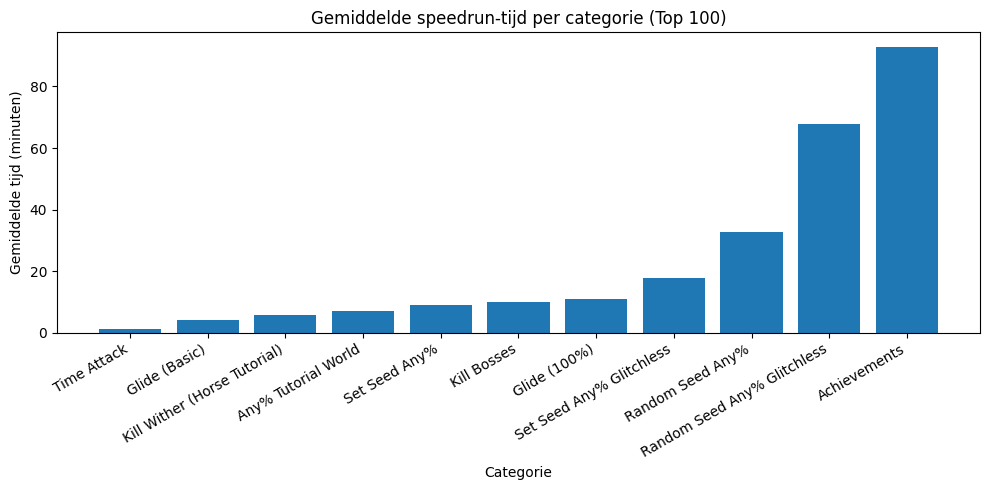

In [119]:
# Gemiddelde tijd per categorie (top 100)
cat_stats = df_top100.groupby('cat_name')['time_min'].mean().sort_values()
print(cat_stats)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cat_stats.index, cat_stats.values)
ax.set_xlabel('Categorie')
ax.set_ylabel('Gemiddelde tijd (minuten)')
ax.set_title('Gemiddelde speedrun-tijd per categorie (Top 100)')
ax.set_xticklabels(cat_stats.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Boxplot per categorie

Met een boxplot zien we niet alleen het gemiddelde, maar ook de **spreiding** en **uitschieters** van de tijden binnen elke categorie.


/var/folders/43/d1ll8jk93n93d7g8f56tk8qh0000gn/T/ipykernel_44607/1504505578.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_cat, labels=categories, showfliers=True)


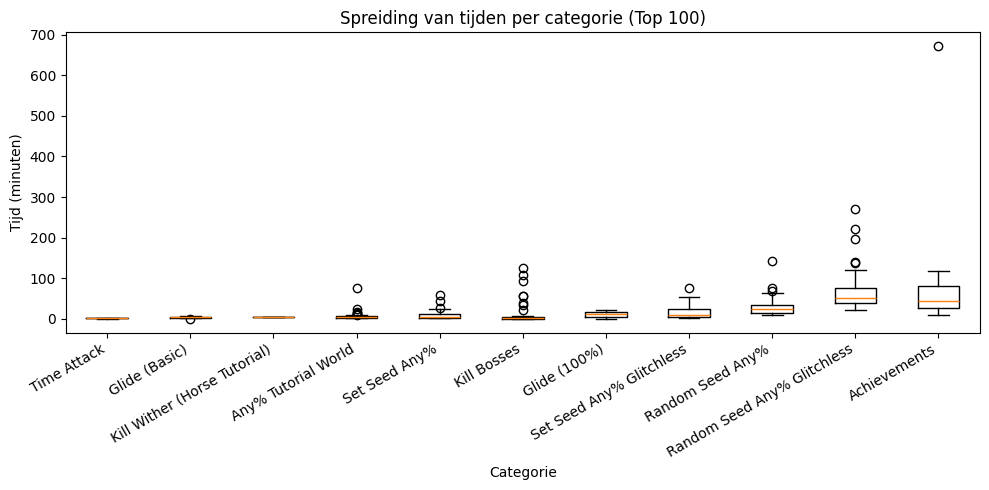

In [120]:
# Boxplot van tijd per categorie (top 100)
categories = cat_stats.index.tolist()
data_per_cat = [df_top100[df_top100['cat_name'] == c]['time_min'] for c in categories]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data_per_cat, labels=categories, showfliers=True)
ax.set_xlabel('Categorie')
ax.set_ylabel('Tijd (minuten)')
ax.set_title('Spreiding van tijden per categorie (Top 100)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 3.3 Violinplot per categorie

Een violinplot lijkt op een boxplot, maar laat ook de **vorm van de verdeling** zien. We kunnen hiermee bijvoorbeeld zien of de verdeling scheef is of meerdere pieken heeft.


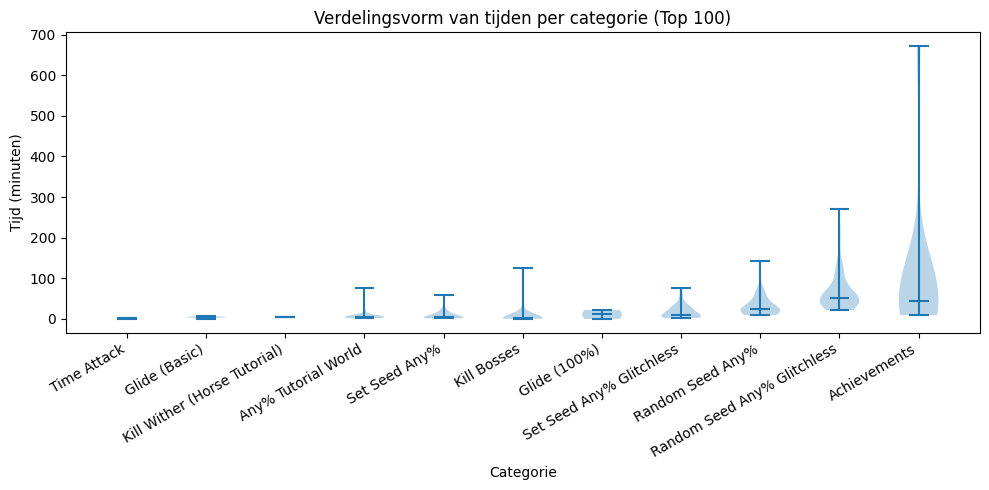

In [121]:
# Violinplot van tijd per categorie (top 100)
fig, ax = plt.subplots(figsize=(10, 5))
parts = ax.violinplot(data_per_cat, showmeans=False, showmedians=True, showextrema=True)

ax.set_xticks(range(1, len(categories) + 1))
ax.set_xticklabels(categories, rotation=30, ha='right')
ax.set_xlabel('Categorie')
ax.set_ylabel('Tijd (minuten)')
ax.set_title('Verdelingsvorm van tijden per categorie (Top 100)')
plt.tight_layout()
plt.show()

### Interpretatie

- De barplot toont **alleen het gemiddelde** per categorie.
- De boxplot laat ook de **spreiding** en **uitschieters** zien.
- De violinplot laat daarnaast de **volledige verdelingsvorm** zien (dikte = dichtheid van runs).

Als de gemiddelde tijd in een categorie duidelijk hoger of lager ligt dan in een andere categorie, impliceert dat een relatie tussen categorie (`cat_name`) en looptijd (`time_min`).

## 4. Bivariate analyse: twee categorische variabelen

We onderzoeken nu de relatie tussen twee categorische variabelen:

- `cat_name` (categorie)
- `platform_name` (platform, bijvoorbeeld PlayStation 4, Wii U, etc.)

We gebruiken een **gestapelde barplot** waarbij elke balk een categorie is en de segmenten de **proporties per platform** binnen die categorie laten zien.


platform_name                 PlayStation 3  PlayStation 4  PlayStation 5  \
cat_name                                                                    
Achievements                              1              5              0   
Any% Tutorial World                      10              9              3   
Glide (100%)                              0              0              0   
Glide (Basic)                             2              0              0   
Kill Bosses                               9             21              4   
Kill Wither (Horse Tutorial)              1              0              0   
Random Seed Any%                          3             11              1   
Random Seed Any% Glitchless               5             26              1   
Set Seed Any%                            11             14              2   
Set Seed Any% Glitchless                  2              9              0   
Time Attack                               0           3000              0   

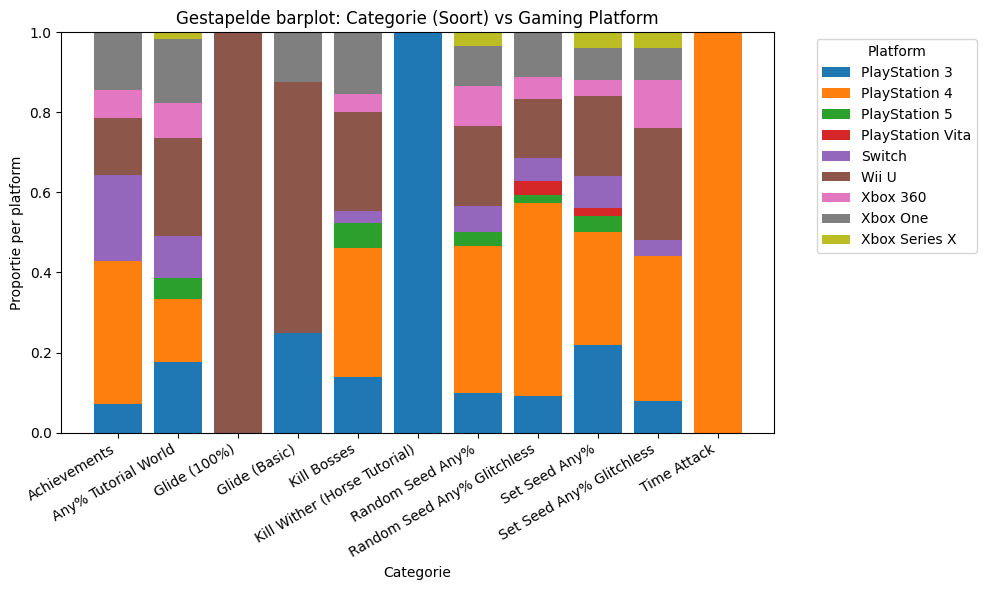

In [122]:
# Frequentietabel cat_name x platform_name
ct = pd.crosstab(df['cat_name'], df['platform_name'])
print(ct)

# Omzetten naar proporties per categorie
ct_prop = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
categories_cc = ct_prop.index.tolist()
platforms = ct_prop.columns.tolist()
x = np.arange(len(categories_cc))
bottom = np.zeros(len(categories_cc))

for platform in platforms:
    values = ct_prop[platform].values
    ax.bar(x, values, bottom=bottom, label=platform)
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(categories_cc, rotation=30, ha='right')
ax.set_xlabel('Categorie')
ax.set_ylabel('Proportie per platform')
ax.set_title('Gestapelde barplot: Categorie (Soort) vs Gaming Platform')
ax.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Interpretatie

- Elke balk stelt een categorie (`cat_name`) voor.
- De hoogte van elk segment geeft de **proportie** runs op een bepaald platform binnen die categorie.
- Grote segmenten voor één platform laten zien dat die categorie vooral op dat platform wordt gespeeld.


## 5. Samenvatting en mogelijke vervolgstappen

In deze bivariate analyse hebben we laten zien:

- Dat er binnen een categorie (bijvoorbeeld **Time Attack**) een duidelijke relatie bestaat tussen plaats en looptijd: langzamere runs hebben een slechtere plaats.
- Dat categorieën sterk verschillen in gemiddelde looptijd en spreiding van tijden.
- Dat sommige categorieën sterk gedomineerd worden door één platform (bijvoorbeeld PlayStation 4).

Mogelijke vervolgstappen:

- Per categorie een aparte regressie-analyse uitvoeren (plaats vs tijd).
- Platformeffecten onderzoeken: zijn runs op bepaalde platforms gemiddeld sneller?
- Effecten van spelerkenmerken (land, ervaring, etc.) toevoegen als extra variabelen.
